# Dependencias y constantes

In [35]:
# Import de librerías importantes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd

# Librerías utilizadas en algunos análisis
from scipy.stats import linregress                  # Para el análisis de regresión lineal
from scipy.stats import kruskal, f_oneway           # Para el test Kruskal-Wallis y ANOVA
from sklearn.linear_model import LinearRegression   # Para la regresión lineal múltiple
from sklearn import tree                            # Para la creación de árboles de decisión
from sklearn.ensemble import RandomForestRegressor  # Para la creación de bosques aleatorios (random forest)


# Para poder cargar los módulos escritos en la raíz del proyecto
from pathlib import Path
import sys

RAIZ_PROYECTO = Path().resolve().parent
sys.path.insert(0, str(RAIZ_PROYECTO))

import src.estadistica as est
import src.representacion as rep

# Para poder recargar los módulos sin tener que reiniciar el kernel
import importlib
importlib.reload(est)
importlib.reload(rep)

R_DATAFRAME = "../datos/out/df_long.csv"            # Ruta del dataframe en csv
DIR_SALIDA = "../salida"

SEMILLA = 1905                                      # Semilla para la generación de números aleatorios
COLUMNA_P = "Pdc"                                   # Nombre de la columna que contiene los valores de potencia

In [36]:
# Funciones muy utilizadas en el cuaderno
def dataframe():
    """Función para cargar el dataframe desde el csv y convertir la columna Datetime a formato datetime."""
    df = pd.read_csv(R_DATAFRAME, parse_dates=['Datetime'])
    return df

# Cuaderno de estudio de configuración de placas

Este cuaderno Jupyter busca comprobar el peso de distintas configuraciones en la disposición de las placas respecto a la potencia que son capaces de generar.

## Comprobación del impacto de la configuración

Uno de los objetivos de este estudio es comprobar si la configuración de las placas tienen un impacto significativo en la potencia generada. Para comprobarlo, se compararán distintas configuraciones y se analizarán los resultados obtenidos.

### Impacto de la posición de las placas

En la planta experimental se encuentran tres posiciones en las que las placas se pueden encontrar instaladas:
1. La izquierda (al este) del grupo.
2. La derecha (al oeste) del grupo.
3. En el centro del grupo.

Esta sección buscará la importancia de la posición de las placas comparando los resultados obtenidos en cada una de las posiciones.

 - P-valor izquierda: 0.01
 - P-valor derecha: 0.01
 - P-valor centro: 0.01
Las series no son normales
Resultados del test:
 - Estadístico: 5286.53761114942
 - P-valor: 0.0
Las series son estadísticamente diferentes


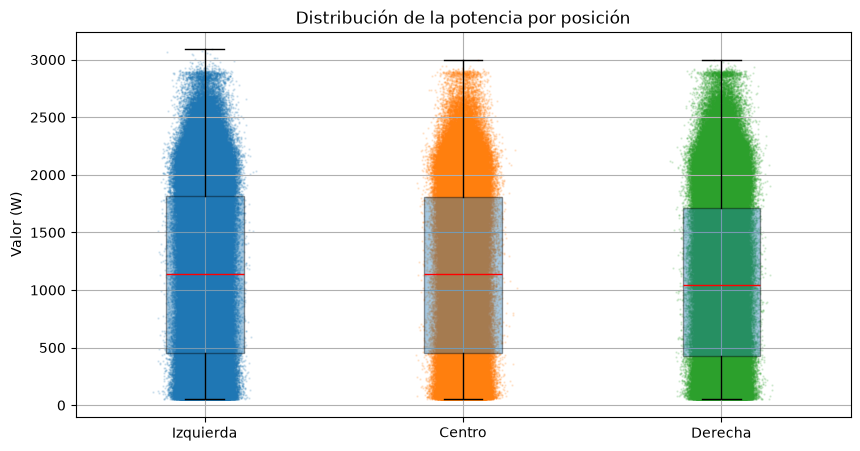

In [37]:
df = dataframe()

# Hago tres columnas nuevas para poder filtrar por posición de las placas
df_izq = df[df["Disp_Izq"] == 1]
df_der = df[df["Disp_Der"] == 1]
df_cent = df[df["Disp_Cent"] == 1]

# Aplico un test de normalidad a cada una de las columnas de interés para ver si se puede aplicar un test anova para comprobar 
# si las series son estadísticamente diferentes.
p_valor_izq = est.test_normalidad(df_izq[COLUMNA_P]).get("pvalor")
p_valor_der = est.test_normalidad(df_der[COLUMNA_P]).get("pvalor")
p_valor_cent = est.test_normalidad(df_cent[COLUMNA_P]).get("pvalor")

print(f" - P-valor izquierda: {p_valor_izq}")
print(f" - P-valor derecha: {p_valor_der}")
print(f" - P-valor centro: {p_valor_cent}")

# Si todos los p-valores son mayores a 0.05 las series son normales
normales = False
if p_valor_izq > 0.05 and p_valor_der > 0.05 and p_valor_cent > 0.05:
    normales = True

print("Las series son normales" if normales else "Las series no son normales")

if not normales:
    # Si las series no son normales, aplico kruskal-wallis para ver si son estadísticamente diferentes
    estadistico, p_valor = kruskal(df_izq[COLUMNA_P], df_der[COLUMNA_P], df_cent[COLUMNA_P])
else:
    # Si lo son, uso anova
    estadistico, p_valor = f_oneway(df_izq[COLUMNA_P], df_der[COLUMNA_P], df_cent[COLUMNA_P])

print(f"Resultados del test:\n - Estadístico: {estadistico}\n - P-valor: {p_valor}")

if p_valor < 0.05:
    print("Las series son estadísticamente diferentes")
else:
    print("Las series no son estadísticamente diferentes")
    
rep.mostrar_boxplot([df_izq[COLUMNA_P], df_cent[COLUMNA_P], df_der[COLUMNA_P]],
                titulos=["Izquierda", "Centro", "Derecha"],
                titulo_figura="Distribución de la potencia por posición",
                u_medida="W")

Sabiendo que la potencia depende de la posición de las placas en el grupo, podemos buscar la mejor posición aplicando un test Wilcoxon para comparar las distribuciones de potencia obtenidas en cada posición. Para ello, se compararán las distribuciones de potencia obtenidas en cada posición.

In [38]:
df = dataframe()

# Hago tres columnas nuevas para poder filtrar por posición de las placas
df_izq = df.where(df["Disp_Izq"] == 1)
df_der = df.where(df["Disp_Der"] == 1)
df_cent = df.where(df["Disp_Cent"] == 1)